In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
print("Hello ML")

Hello ML


In [2]:
housing_full = pd.read_csv(Path("datasets/housing/housing.csv"))

In [3]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


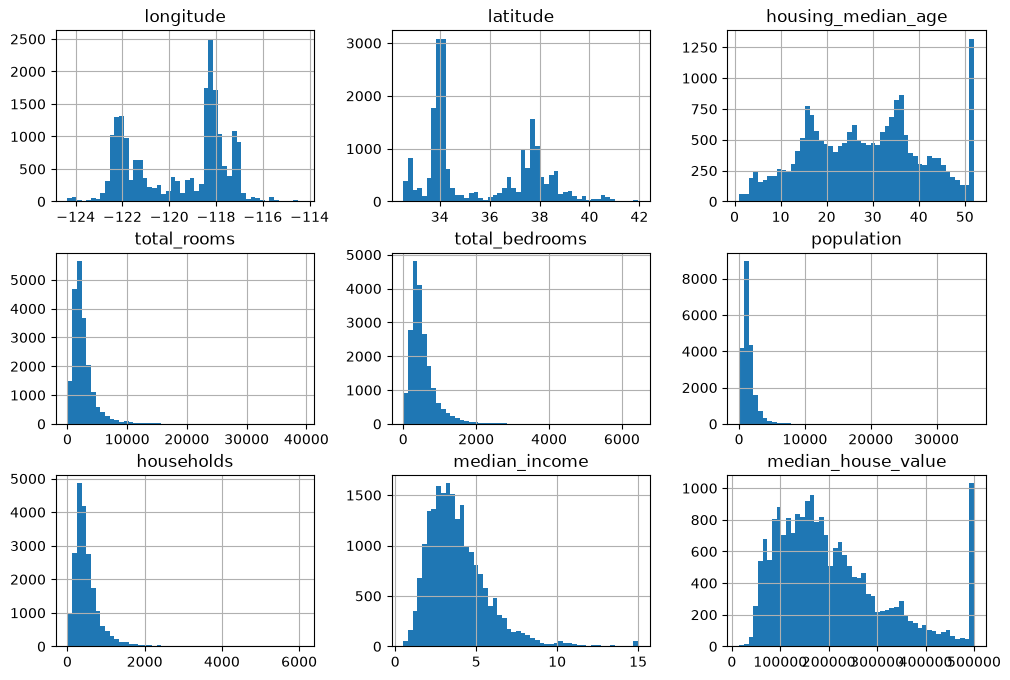

In [6]:
housing_full.hist(bins=50, figsize=(12, 8))
plt.show()

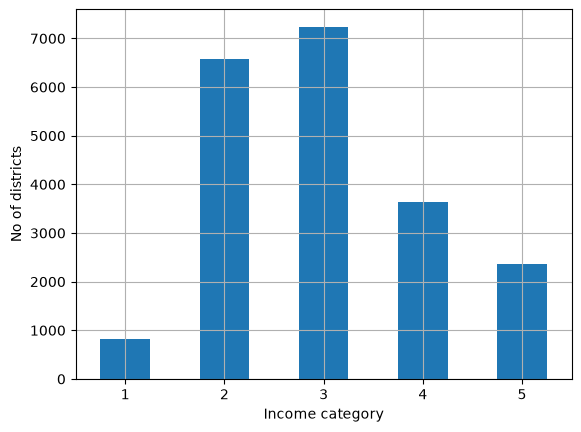

1316.2


In [7]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0,1.5,3.0,4.5,6, np.inf],
                                    labels=[1,2,3,4,5])

cat_counts = housing_full['income_cat'].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid = True)
plt.xlabel("Income category")
plt.ylabel("No of districts")
plt.show()
print(cat_counts[2]*0.2)

In [8]:
#Random sampling into train and test set:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split( housing_full, test_size=0.2, random_state=42)

In [9]:
test_set["income_cat"].value_counts()

income_cat
3    1425
2    1269
4     760
5     499
1     175
Name: count, dtype: int64

In [10]:
#Stratified sampling into train and test set:
strat_train_set, strat_test_set = train_test_split( housing_full, test_size=0.2, random_state=42, stratify=housing_full["income_cat"])

In [11]:
strat_test_set["income_cat"].value_counts()

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

Now after spliting we can delete income_cat column from splits cause it can make our model learn extra noise and overfit th data.

As we original data doesn't contain categories and we aren't using input data to find category and give it to model.

so drop the column

In [12]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

As in cell 16 we catogorized whole dataset and also printed no of districts of category 2 and in two different sampling and spliting methods random and stratified(median income) we got train set and test set.

So the value printed in cell 16 is 20% of no of districts belonging to 2nd category = 1316.2

And we extracted exact values of eac categories in test set derived from both ways(random and stratified(median income)).

We can see in random (2nd cat) = 1269
while in stratified (end cat) = 1316

So closer value to 1316.2 is in stratified sampling so its important to have train and test sets stratified means having similar data distribution/

Conclusion: we always you well distributed and stratified data to get good test instances which can train and validate our model in all aspects.

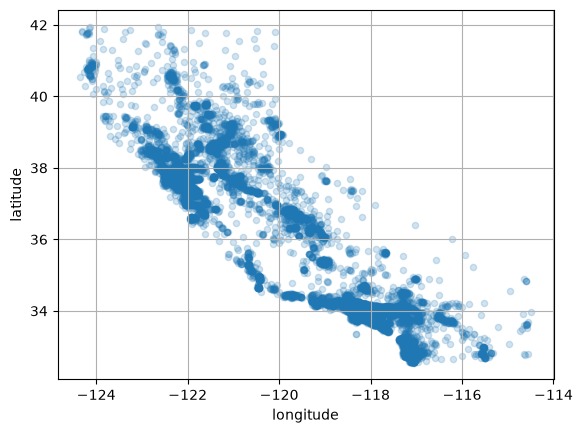

In [13]:
#Visualize geographical data. alpha helps to focus on denser regions.
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

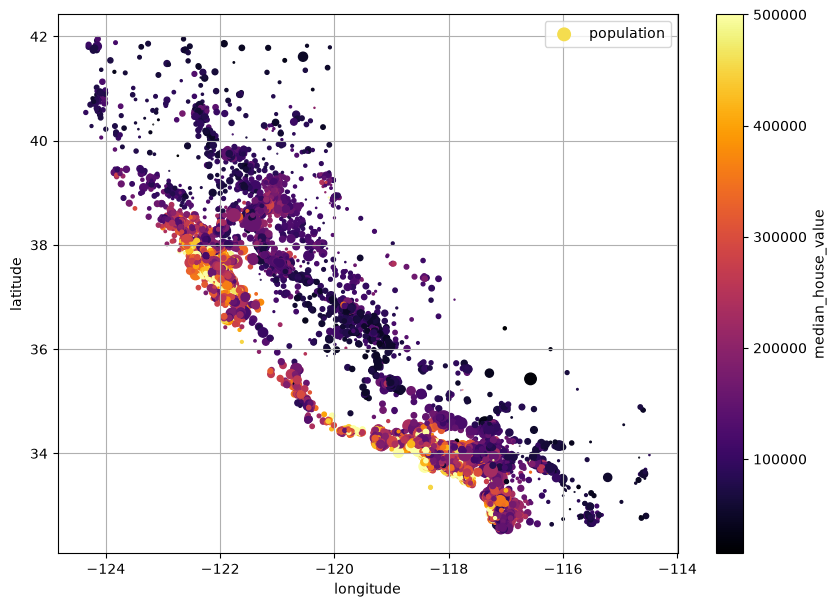

In [14]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
            s=housing["population"] / 100, label="population",
            c="median_house_value", cmap="inferno", colorbar=True,
            legend=True, sharex=False, figsize=(10,7))
plt.show()

We can see prime locations are BAY, costal and lowers regions, we can say that housing prices are dependent on location and population density. We need to find these patterns and Correlations.

In [16]:
corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

Found correlation of each attribute with median house value, to get relation and it varies from -1 to 1 